# Anomalous Financial Transaction Detection

본 대회의 과제는 금융 거래 데이터에서 **이상 거래를 탐지하는 기능**을 개선하고 활용도를 높이는 분류 AI모델을 개발하는 것입니다. 

특히, 클래스 불균형 문제를 해결하기 위해 오픈소스 생성형 AI 모델을 활용하여 부족한 클래스의 데이터를 보완하고, 이를 통해 분류 모델의 성능을 향상시키는 것이 핵심 목표입니다. 

이러한 접근을 통해 금융보안에 특화된 데이터 분석 및 활용 역량을 강화하여 전문 인력을 양성하고, 금융권의 AI 활용 어려움에 따른 해결 방안을 함께 모색하며 금융 산업의 AI 활용 활성화를 지원하는 것을 목표로 합니다.

# Import Library

In [52]:
# 제출 파일 생성 관련
import os
import zipfile

# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows의 경우 'Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 머신러닝 전처리
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# 머신러닝 모델
import xgboost as xgb

# 합성 데이터 생성
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

# To ignore all warnings
import warnings
warnings.filterwarnings('ignore')

# 생성 🏭

# Load Data

In [ ]:
# 테스트 데이터 컬럼명 맞춰주기
#train_re 파일과 test 파일이 존재해야하며 이 셀을 실행한 뒤에는 해당 폴더에 train_re와 test_re 파일이 존재해야함

#train_re = pd.read_csv("open/train_re.csv") # 경로는 각자 지정
#test = pd.read_csv("open/test.csv")
#
## train_re의 컬럼명 가져와서 test에 적용
#test.columns = train_re.drop(columns='사기_유형').columns  # test에는 '사기_유형'이 없음
#test.columns
#test.to_csv("open/test_re.csv", index=False, encoding='utf-8-sig')

In [31]:
train_all = pd.read_csv("open/train_re.csv") # 경로는 각자 지정
test_all = pd.read_csv("open/test_re.csv") # 경로는 각자 지정

In [32]:
train = train_all.drop(columns="거래_ID")

In [33]:
train["사기_유형"].value_counts()

사기_유형
m    118800
a       100
j       100
h       100
k       100
c       100
g       100
i       100
b       100
f       100
d       100
e       100
l       100
Name: count, dtype: int64

In [56]:
train.columns

Index(['고객_출생년도', '고객_성별', '고객_개인식별자', '고객_식별번호', '고객_등록일시', '고객_신용등급',
       '인증수단_변경플래그1', '인증수단_변경플래그2', '인증수단_변경플래그3', '인증수단_변경플래그4', '루팅_탈옥여부',
       '모바일_로밍여부', 'VPN_사용여부', '고객_대출유형', '단말기_악성행동플래그1', '단말기_악성행동플래그2',
       '단말기_악성행동플래그3', '단말기_악성행동플래그4', '단말기_악성행동플래그5', '단말기_악성행동플래그6',
       'ATM_한도조회횟수', 'ATM_한도증가요청', '계좌_번호', '계좌_종류', '계좌_개설일시', '계좌_최초잔액',
       '현재_계좌잔액', '한도초과여부', '하루이체한도금액', '오픈뱅킹등록여부', '하루한도초과후남은금액', '출금정지여부',
       '1개월최대거래금액', '1개월거래금액표준편차', '1개월새벽최대거래금액', '1개월새벽거래금액표준편차', '거래_일시',
       '거래_금액', '거래_채널', '사용_OS', '오류코드', '거래_실패_여부', '자동이체_거래_구분', 'IP_주소',
       'MAC_주소', '접속_매체', '거래_위치', '수취인_계좌번호', '거래_접속_실패_횟수', '타인_계좌_여부', '거리',
       '거래시간_차이', '미사용_단말기_상태', '마지막_ATM_거래_시간', '마지막_은행지점_거래_시간',
       '천만원초과_입금_플래그', '미사용_계좌_상태', '수취인_계좌_정지여부', '계좌별_거래건수', '계좌_거래내역지수',
       '취약사용자의_iOS첫사용', '사기_유형', '거래_재개일시', '거래시간_차이_seconds'],
      dtype='object')

A는 거리가 다른곳의 2배 이상 350근처
B는 아이폰 루팅 탈옥 비중이 0.5.이상임+ 로밍과 VPN 높음 + 한도조회 및 증가요청
C는 악성행동 플러그 0.7이상 + 복합 이상여부 100% + 고객등급C,d,e등급 100%
D
E는 ATM기를 통한 사기 + 금액 1000만원초과
F는 아예 다른 채널을 통한 사기+ 한도조회 및 증가요청 + 금액 1000만원초과 + 최초잔액이 높고 이후잔액이 낮음
G
H는 1개월 거래금액 자체가 낮고 거래금액 표준편차가 0이며 + 한도조회 및 증가요청 + 거래실패율이 높음(잔액부족)
I는 거래금액 자체가 높은 곳으로 형성 + 3개월이내 인증서 발급(4개이상)+ 담보대출100% + 나이 많음
J는 미사용 계좌 및 수취인 계좌 정지
K는 계좌별 거래건수 많음 + 3개월이내 인증서 발급(4개이상)


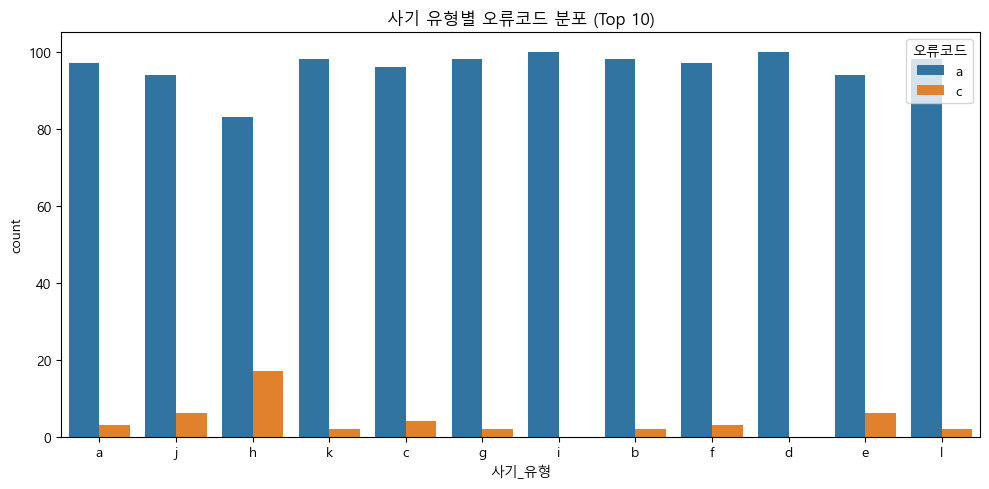

In [128]:
# 사기 유형별 오류코드 분포
plt.figure(figsize=(10, 5))
top_categories = fraud['오류코드'].value_counts().index[:10]
sns.countplot(data=fraud[fraud['오류코드'].isin(top_categories)], x='사기_유형', hue='오류코드')
plt.title("사기 유형별 오류코드 분포 (Top 10)")
plt.tight_layout()
plt.show()



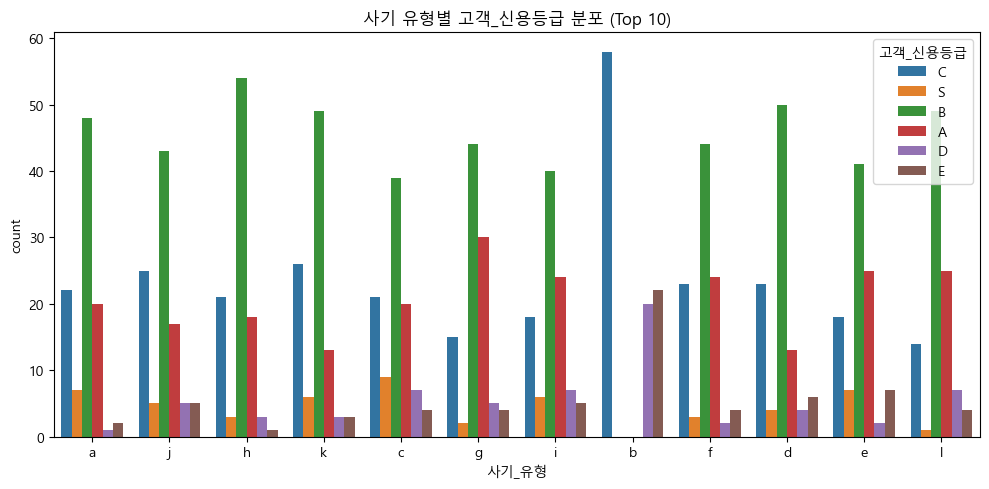

In [122]:
# 사기 유형별 고객_신용등급 분포 (Top 10)
plt.figure(figsize=(10, 5))
top_categories = fraud['고객_신용등급'].value_counts().index[:10]
sns.countplot(data=fraud[fraud['고객_신용등급'].isin(top_categories)], x='사기_유형', hue='고객_신용등급')
plt.title("사기 유형별 고객_신용등급 분포 (Top 10)")
plt.tight_layout()
plt.show()



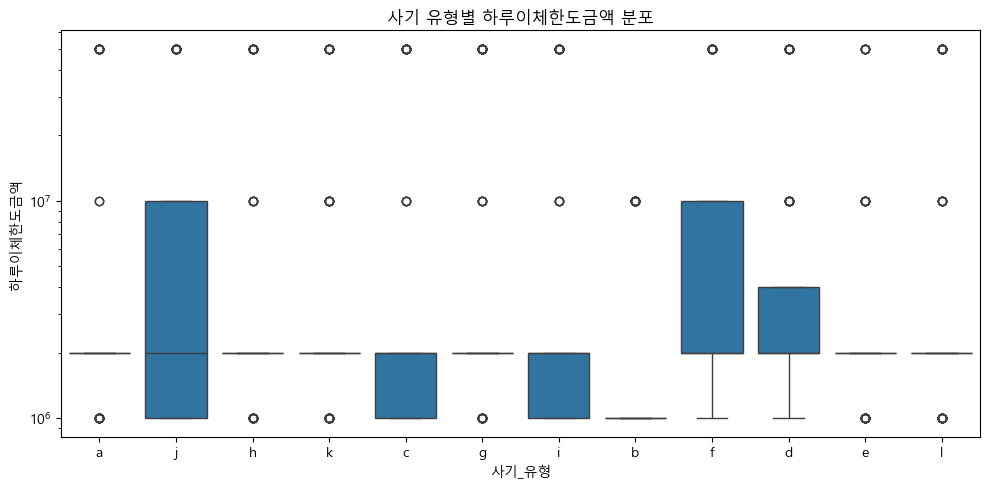

In [116]:
# 사기 유형별 하루이체한도금액 분포
plt.figure(figsize=(10, 5))
sns.boxplot(data=fraud, x='사기_유형', y='하루이체한도금액')
plt.yscale('log')
plt.title("사기 유형별 하루이체한도금액 분포")
plt.tight_layout()
plt.show()


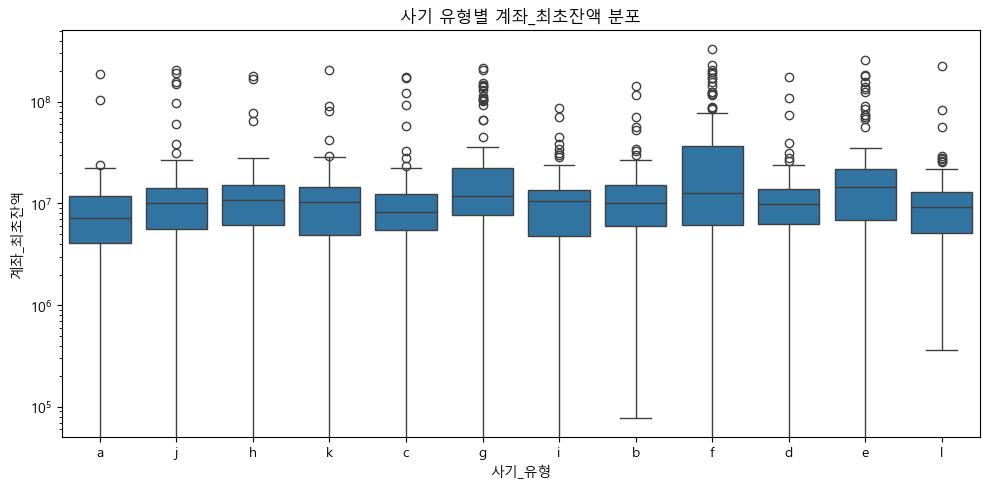

In [114]:
# 사기 유형별 계좌_최초잔액 분포
plt.figure(figsize=(10, 5))
sns.boxplot(data=fraud, x='사기_유형', y='계좌_최초잔액')
plt.yscale('log')
plt.title("사기 유형별 계좌_최초잔액 분포")
plt.tight_layout()
plt.show()





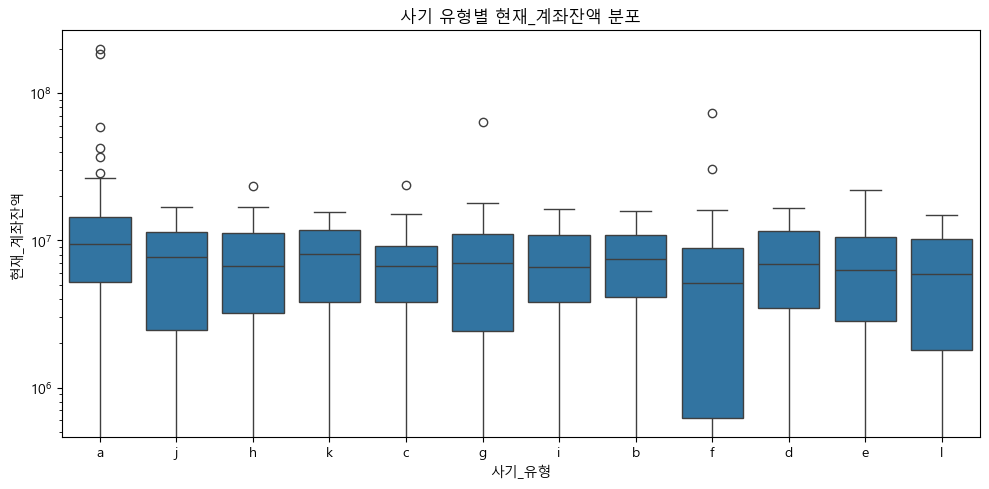

In [115]:
# 사기 유형별 현재_계좌잔액 분포
plt.figure(figsize=(10, 5))
sns.boxplot(data=fraud, x='사기_유형', y='현재_계좌잔액')
plt.yscale('log')
plt.title("사기 유형별 현재_계좌잔액 분포")
plt.tight_layout()
plt.show()


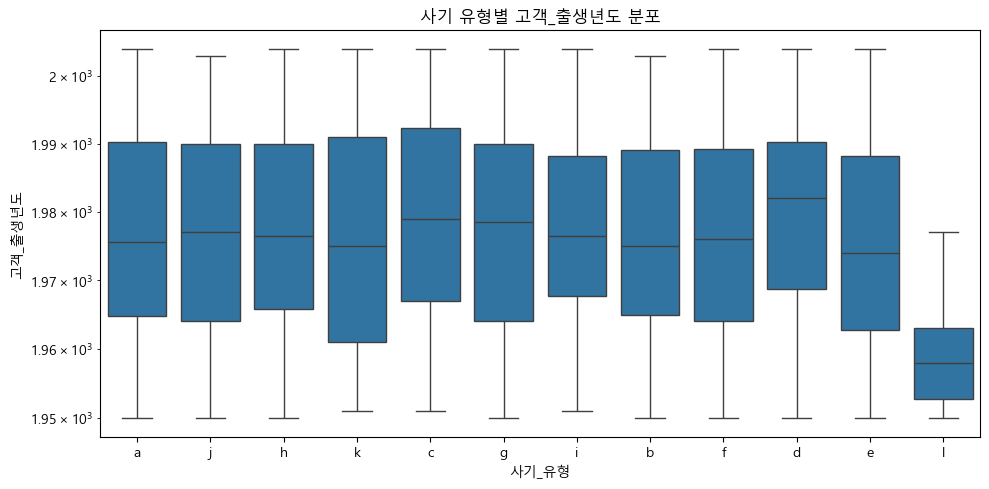

In [107]:
# 사기 유형별 고객_출생년도 분포
plt.figure(figsize=(10, 5))
sns.boxplot(data=fraud, x='사기_유형', y='고객_출생년도')
plt.yscale('log')
plt.title("사기 유형별 고객_출생년도 분포")
plt.tight_layout()
plt.show()


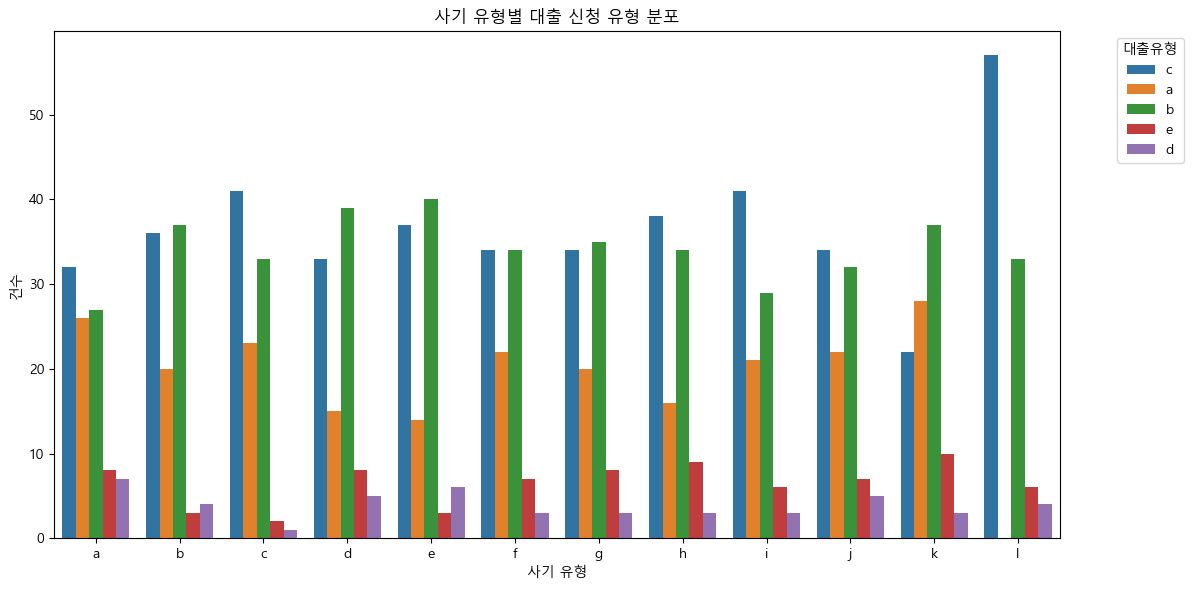

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# 사기 데이터만 필터링
fraud = train[train['사기_유형'] != 'm']

# 시각화
plt.figure(figsize=(12, 6))
sns.countplot(data=fraud, x='사기_유형', hue='고객_대출유형', order=sorted(fraud['사기_유형'].unique()))
plt.title("사기 유형별 대출 신청 유형 분포")
plt.xlabel("사기 유형")
plt.ylabel("건수")
plt.legend(title="대출유형", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


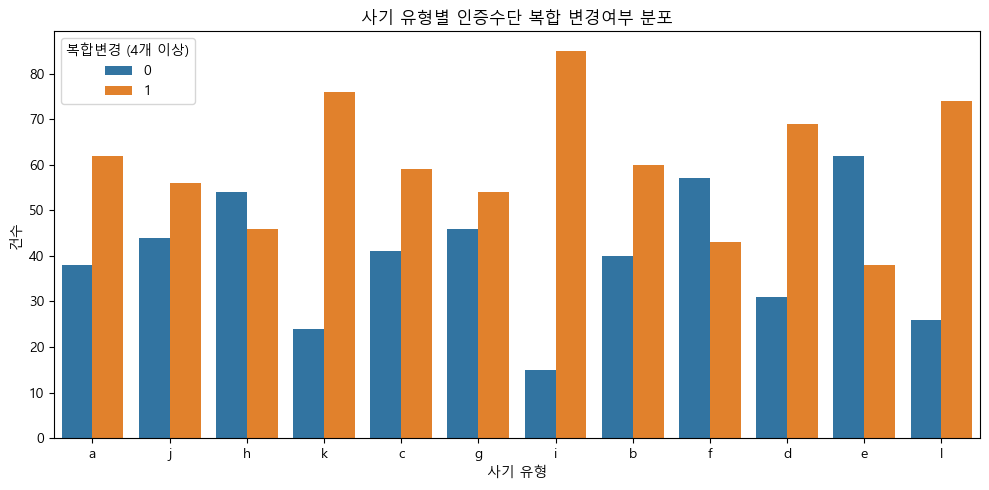

In [105]:
# 1~4번 인증수단 변경 플래그 컬럼 목록
change_flags = [f'인증수단_변경플래그{i}' for i in range(1, 5)]

# 변경 플래그 합계
train['인증수단_변경합계'] = train[change_flags].sum(axis=1)

# 3개 이상 변경한 경우 플래그
train['인증수단_복합변경여부'] = (train['인증수단_변경합계'] >= 4).astype(int)
import seaborn as sns
import matplotlib.pyplot as plt

fraud = train[train['사기_유형'] != 'm']

plt.figure(figsize=(10, 5))
sns.countplot(data=fraud, x='사기_유형', hue='인증수단_복합변경여부')
plt.title("사기 유형별 인증수단 복합 변경여부 분포")
plt.xlabel("사기 유형")
plt.ylabel("건수")
plt.legend(title="복합변경 (4개 이상)")
plt.tight_layout()
plt.show()

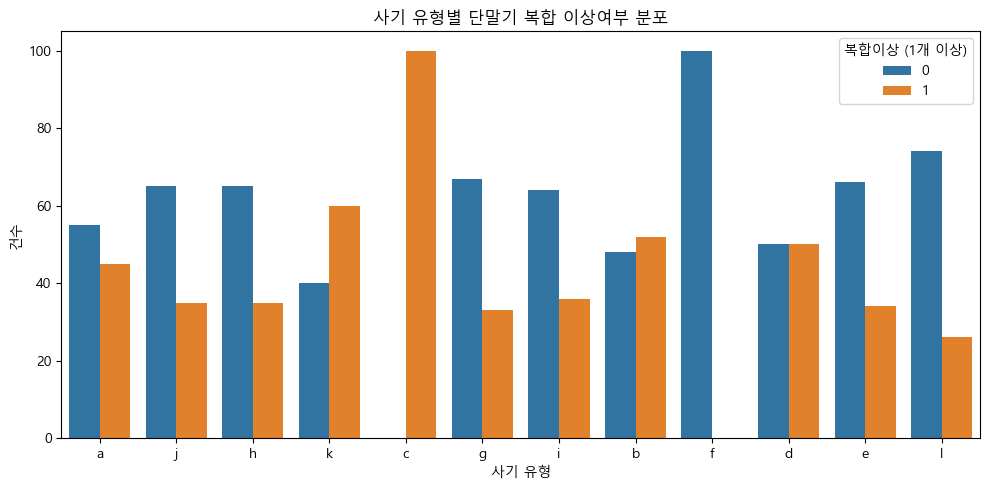

In [99]:
malicious_flags = [f'단말기_악성행동플래그{i}' for i in range(1, 7)]
train['단말기_이상합계'] = train[malicious_flags].sum(axis=1)
train['단말기_복합이상여부'] = (train['단말기_이상합계'] >= 1).astype(int)
import seaborn as sns
import matplotlib.pyplot as plt

# 사기 거래만 필터링
fraud = train[train['사기_유형'] != 'm']

# 시각화: 사기유형별 복합이상여부 분포
plt.figure(figsize=(10, 5))
sns.countplot(data=fraud, x='사기_유형', hue='단말기_복합이상여부')
plt.title("사기 유형별 단말기 복합 이상여부 분포")
plt.xlabel("사기 유형")
plt.ylabel("건수")
plt.legend(title="복합이상 (1개 이상)")
plt.tight_layout()
plt.show()


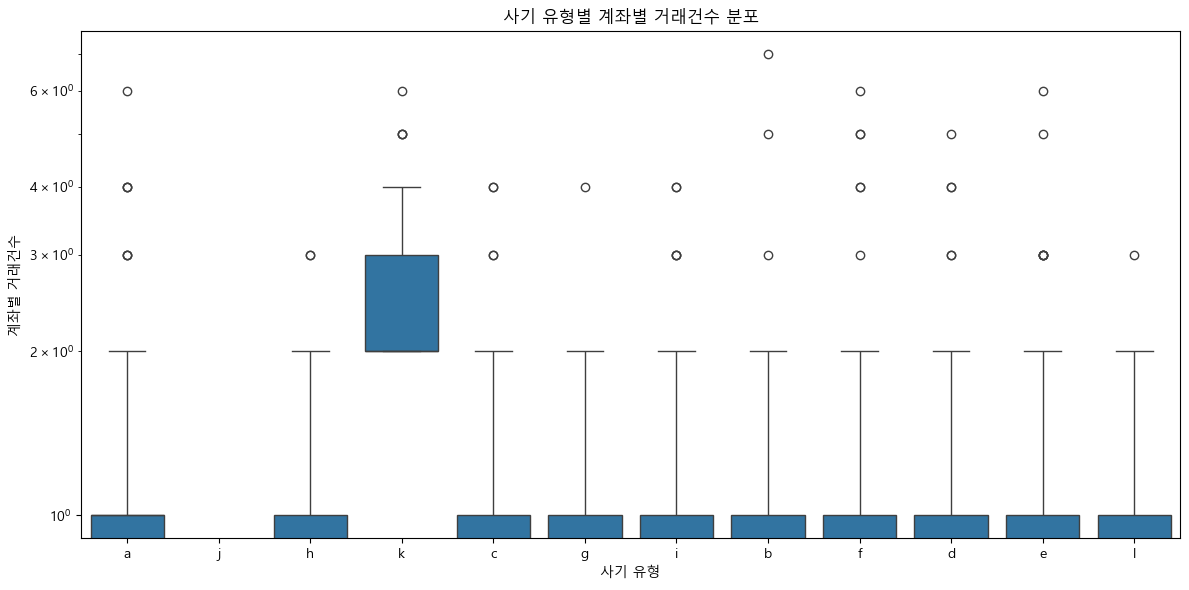

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# 사기 데이터만 필터링
fraud = train[train['사기_유형'] != 'm']

# boxplot: 거래건수 분포
plt.figure(figsize=(12, 6))
sns.boxplot(data=fraud, x='사기_유형', y='계좌별_거래건수')
plt.yscale('log')  # 편차가 크면 로그 스케일 유용
plt.title("사기 유형별 계좌별 거래건수 분포")
plt.xlabel("사기 유형")
plt.ylabel("계좌별 거래건수")
plt.tight_layout()
plt.show()

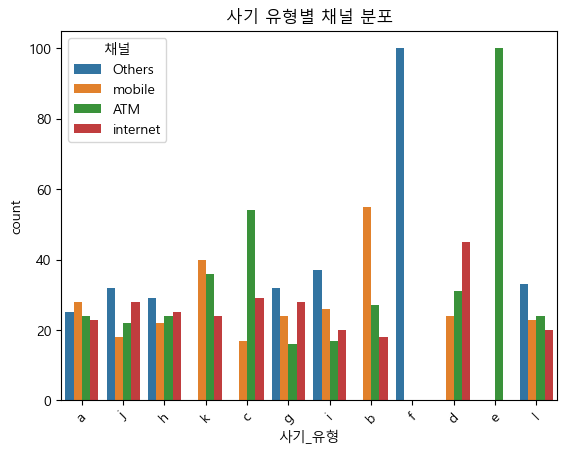

In [53]:
sns.countplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', hue='거래_채널')
plt.title("사기 유형별 채널 분포")
plt.xticks(rotation=45)
plt.legend(title='채널')
plt.show()

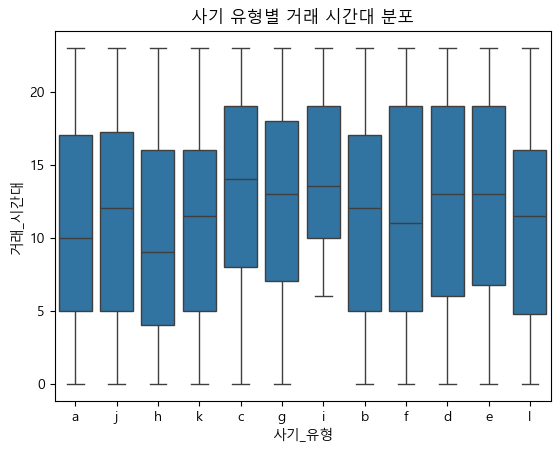

In [57]:
# 거래 시각 파싱
train['거래_일시'] = pd.to_datetime(train['거래_일시'])
train['거래_시간대'] = train['거래_일시'].dt.hour  # 시각만 추출

# 시각별 사기유형 분포
import seaborn as sns
sns.boxplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='거래_시간대')
plt.title("사기 유형별 거래 시간대 분포")
plt.show()


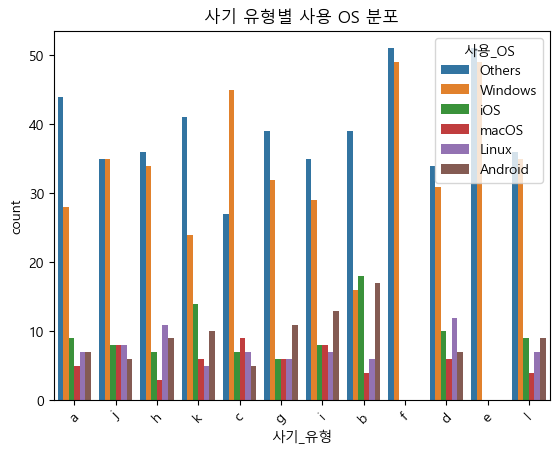

In [58]:
sns.countplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', hue='사용_OS')
plt.title("사기 유형별 사용 OS 분포")
plt.xticks(rotation=45)
plt.show()


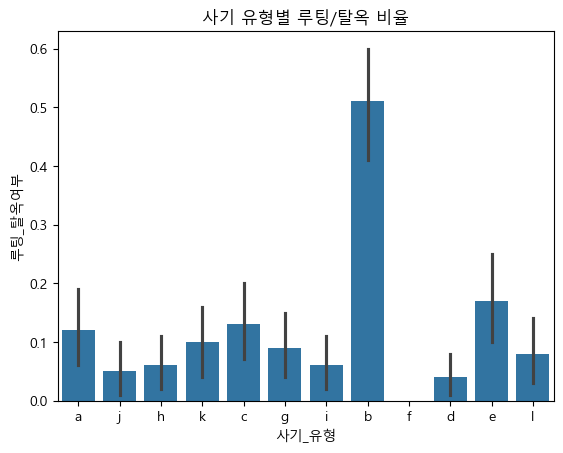

In [60]:
sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='루팅_탈옥여부')
plt.title("사기 유형별 루팅/탈옥 비율")
plt.show()


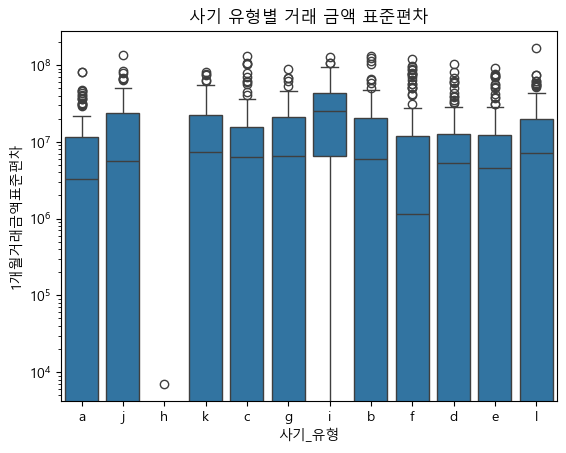

In [61]:
sns.boxplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='1개월거래금액표준편차')
plt.yscale('log')
plt.title("사기 유형별 거래 금액 표준편차")
plt.show()


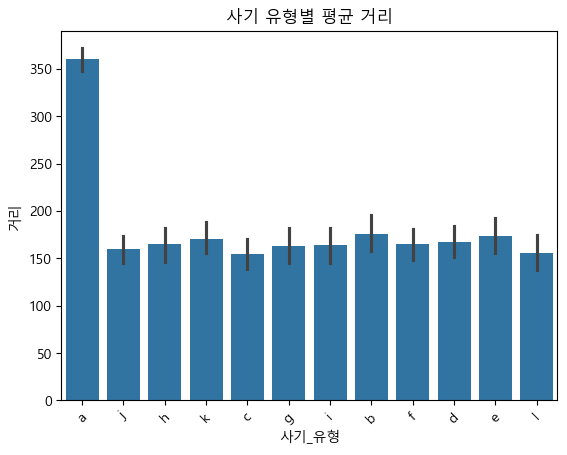

In [54]:
import numpy as np

sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='거리', estimator=np.mean)
plt.title("사기 유형별 평균 거리")
plt.xticks(rotation=45)
plt.show()

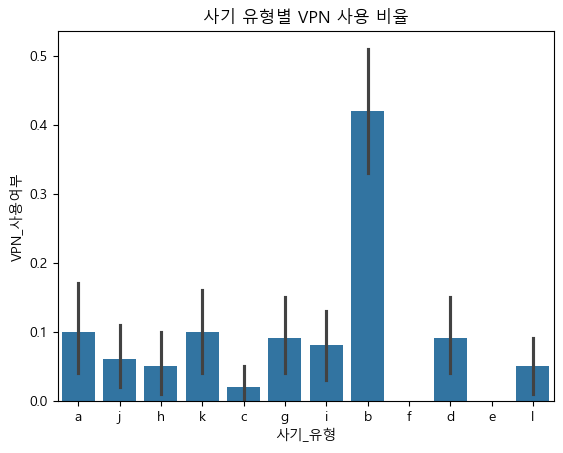

In [63]:
sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='VPN_사용여부')
plt.title("사기 유형별 VPN 사용 비율")
plt.show()


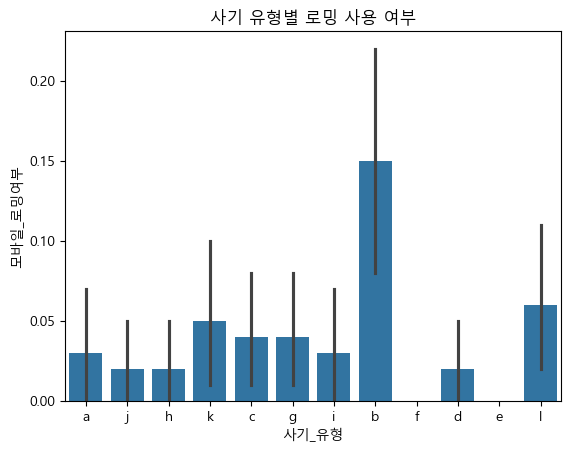

In [64]:
sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='모바일_로밍여부')
plt.title("사기 유형별 로밍 사용 여부")
plt.show()


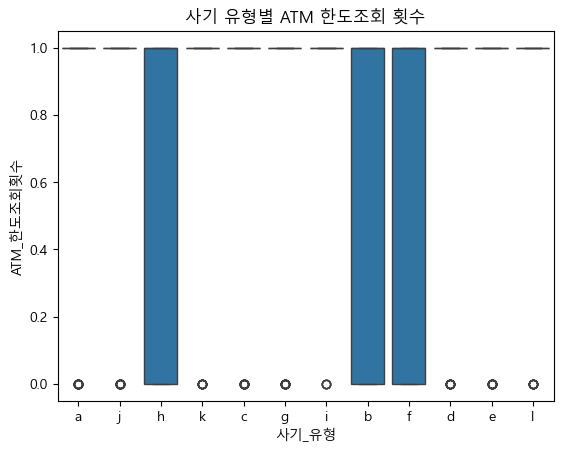

In [65]:
sns.boxplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='ATM_한도조회횟수')
plt.title("사기 유형별 ATM 한도조회 횟수")
plt.show()


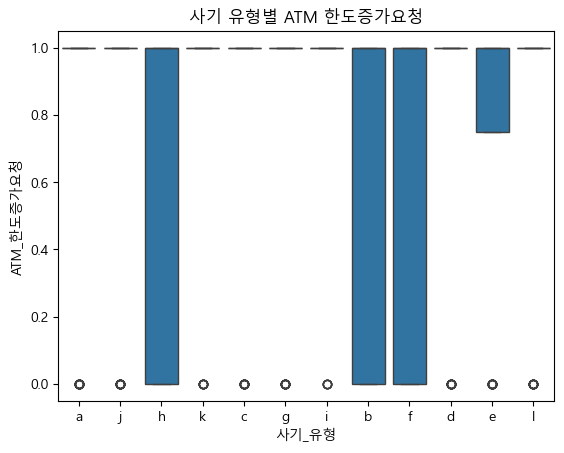

In [76]:
sns.boxplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='ATM_한도증가요청')
plt.title("사기 유형별 ATM 한도증가요청")
plt.show()

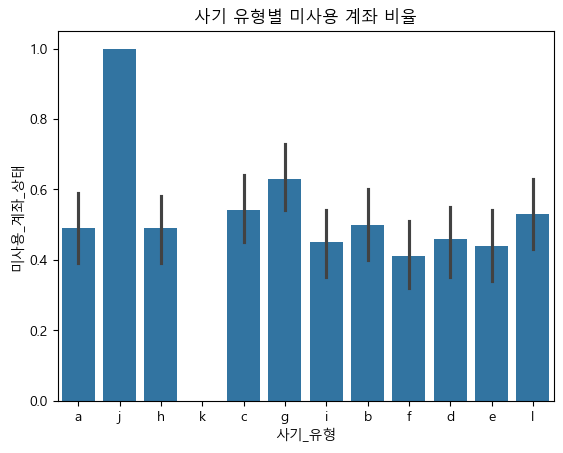

In [66]:
sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='미사용_계좌_상태')
plt.title("사기 유형별 미사용 계좌 비율")
plt.show()


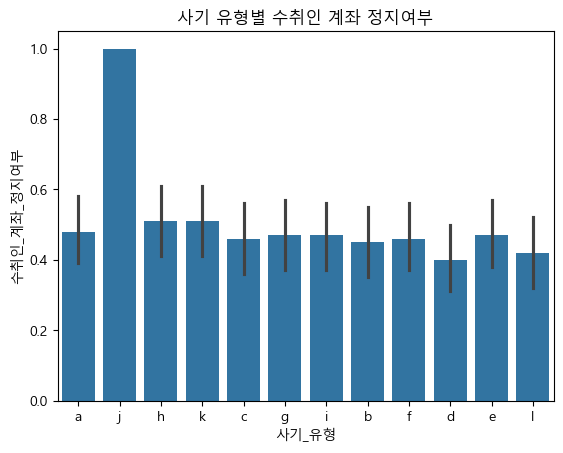

In [67]:
sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='수취인_계좌_정지여부')
plt.title("사기 유형별 수취인 계좌 정지여부")
plt.show()


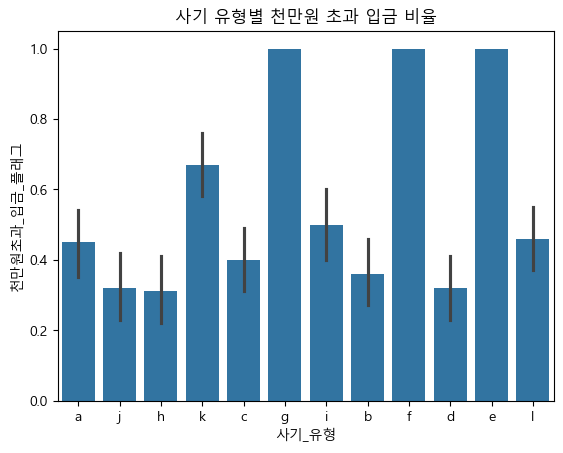

In [68]:
sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='천만원초과_입금_플래그')
plt.title("사기 유형별 천만원 초과 입금 비율")
plt.show()


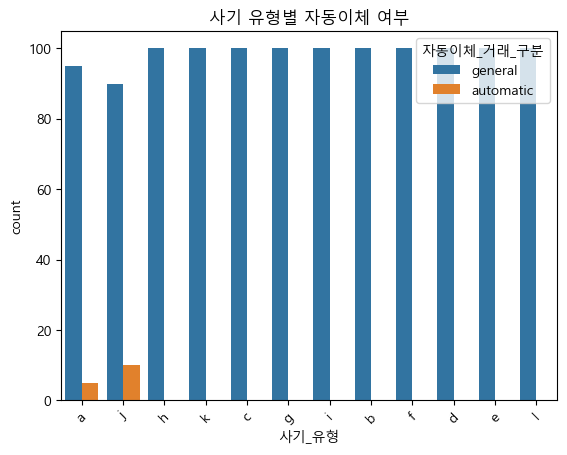

In [69]:
sns.countplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', hue='자동이체_거래_구분')
plt.title("사기 유형별 자동이체 여부")
plt.legend(title='자동이체_거래_구분')
plt.xticks(rotation=45)
plt.show()


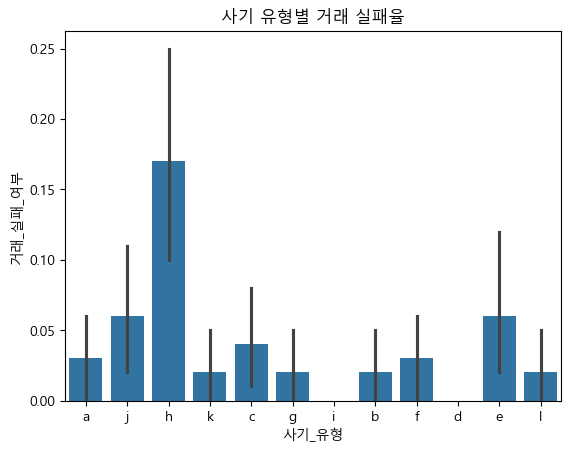

In [70]:
sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y='거래_실패_여부')
plt.title("사기 유형별 거래 실패율")
plt.show()


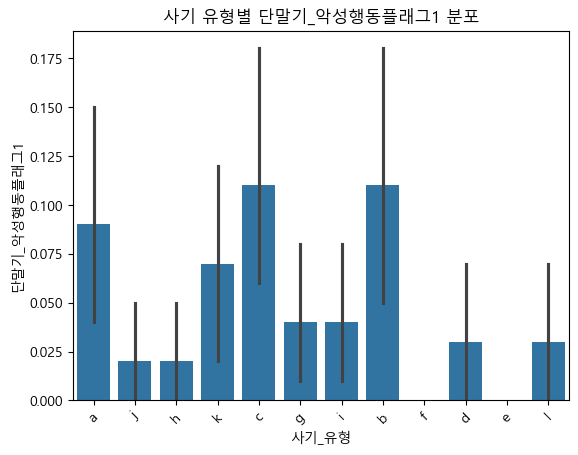

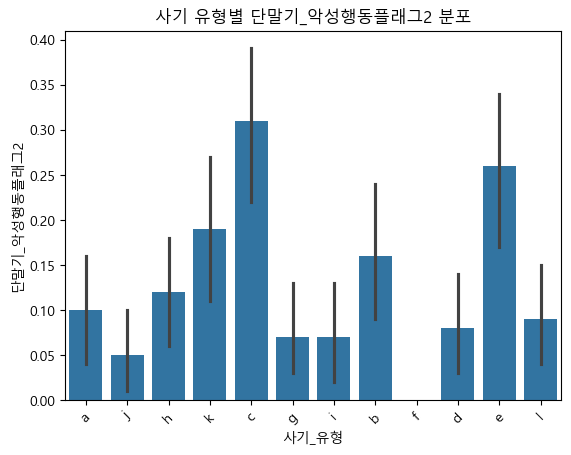

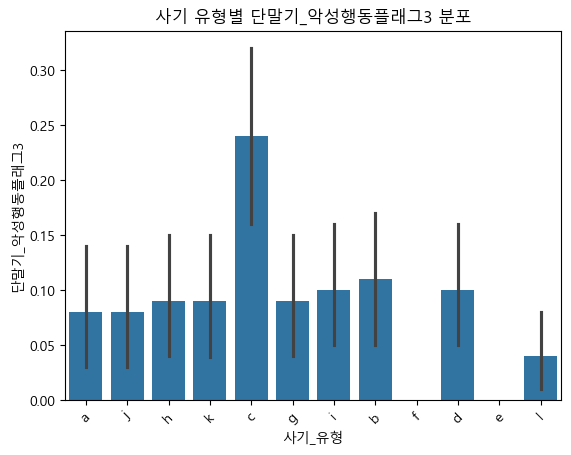

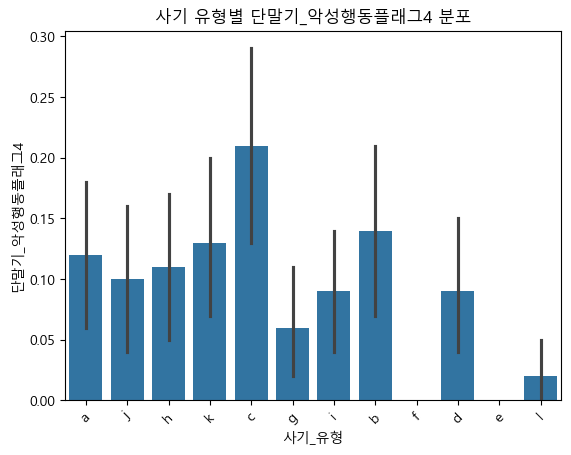

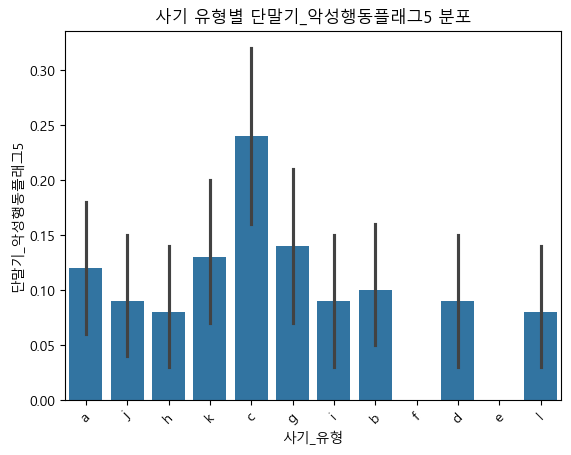

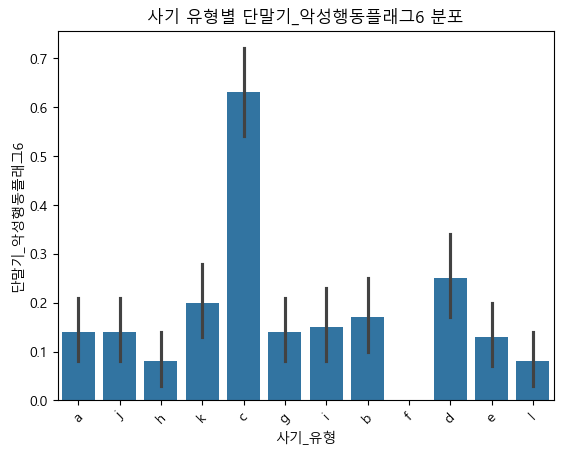

In [71]:
for i in range(1, 7):
    col = f'단말기_악성행동플래그{i}'
    sns.barplot(data=train[train['사기_유형'] != 'm'], x='사기_유형', y=col)
    plt.title(f"사기 유형별 {col} 분포")
    plt.xticks(rotation=45)
    plt.show()


In [34]:
'''
(*) 리더보드 산식 중 생성데이터의 익명성(TCAP)채점을 위해 각 클래스 별로 1000개의 생성데이터가 반드시 필요합니다.
(*) 본 베이스 라인에서는 "사기_유형" 13종류에 대해 1000개씩 , 총 13,000개의 데이터를 생성할 예정입니다.
(*) 분류 모델 성능 개선을 위해 생성 데이터를 활용하는 것에는 생성 데이터의 Row 개수에 제한이 없습니다. 단, 리더보드 평가를 위해 제출을 하는 생성 데이터 프레임은 익명성(TCAP) 평가를 위함이며, 위의 조건을 갖춘 생성 데이터를 제출해야합니다.
'''
N_CLS_PER_GEN = 1000


In [35]:

# 이상치 처리 함수
def handle_outliers(series, n_std=3):
    mean = series.mean()
    std = series.std()
    z_scores = np.abs(stats.zscore(series))
    return series.mask(z_scores > n_std, mean)

# 거래시간_차이 컬럼을 총 초로 변환 및 이상치 처리
train['거래시간_차이_seconds'] = pd.to_timedelta(train['거래시간_차이']).dt.total_seconds()
train['거래시간_차이_seconds'] = handle_outliers(train['거래시간_차이_seconds'])


# 모든 사기_유형 목록 생성 (m 포함)
fraud_types = train['사기_유형'].unique()

# 모든 합성 데이터를 저장할 DataFrame 초기화
all_synthetic_data = pd.DataFrame()

N_SAMPLE = 100

# 각 사기_유형에 대해 합성 데이터 생성 및 저장
for fraud_type in tqdm(fraud_types):
    
    # 해당 사기_유형에 대한 서브셋 생성
    subset = train[train["사기_유형"] == fraud_type]

    # 모든 사기_유형에 대해 100개씩 샘플링
    subset = subset.sample(n=N_SAMPLE, random_state=42)
    
    # 거래시간_차이 열 제외 (초 단위로 변환된 컬럼만 사용)
    subset = subset.drop('거래시간_차이', axis=1)
    
    # 메타데이터 생성 및 모델 학습
    metadata = SingleTableMetadata()

    metadata.detect_from_dataframe(subset)
    metadata.set_primary_key(None)

    # 데이터 타입 설정
    column_sdtypes = {
        '계좌_최초잔액': 'numerical',
        '현재_계좌잔액': 'numerical',
        '고객_식별번호': 'categorical',  
        '고객_개인식별자': 'categorical',
        '계좌_번호': 'categorical',
        'IP_주소': 'ipv4_address',  
        '거래_위치': 'categorical',
        '수취인_계좌번호': 'categorical',
        '사기_유형': 'categorical',
        '거래시간_차이_seconds': 'numerical',
        '고객_출생년도': 'numerical'
    }

    # 각 컬럼에 대해 데이터 타입 설정
    for column, sdtype in column_sdtypes.items():
        metadata.update_column(
            column_name=column,
            sdtype=sdtype
        )
        
    synthesizer = CTGANSynthesizer(
                            metadata,
                            epochs=100
                        )
    synthesizer.fit(subset)

    synthetic_subset = synthesizer.sample(num_rows=N_CLS_PER_GEN)
    
    # 생성된 거래시간_차이_seconds의 이상치 처리
    synthetic_subset['거래시간_차이_seconds'] = handle_outliers(synthetic_subset['거래시간_차이_seconds'])
    
    # 거래시간_차이_seconds를 다시 timedelta로 변환
    synthetic_subset['거래시간_차이'] = pd.to_timedelta(synthetic_subset['거래시간_차이_seconds'], unit='s')
    
    # 거래시간_차이_seconds 컬럼 제거
    synthetic_subset = synthetic_subset.drop('거래시간_차이_seconds', axis=1)
    
    # 생성된 데이터를 all_synthetic_data에 추가
    all_synthetic_data = pd.concat([all_synthetic_data, synthetic_subset], ignore_index=True)
# 최종 결과 확인
print("\nFinal All Synthetic Data Shape:", all_synthetic_data.shape)

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [03:13<00:00, 14.86s/it]


Final All Synthetic Data Shape: (13000, 63)


In [36]:
all_synthetic_data.head() # 잘 변환되었는지 확인하는 과정입니다.

,고객_출생년도,고객_성별,고객_개인식별자,고객_식별번호,고객_등록일시,고객_신용등급,인증수단_변경플래그1,인증수단_변경플래그2,인증수단_변경플래그3,인증수단_변경플래그4,...,마지막_은행지점_거래_시간,천만원초과_입금_플래그,미사용_계좌_상태,수취인_계좌_정지여부,계좌별_거래건수,계좌_거래내역지수,취약사용자의_iOS첫사용,사기_유형,거래_재개일시,거래시간_차이
0,1988,male,김정훈,sVEclt-NjrTYLA,2004-05-21 03:34:51,C,1,1,1,0,...,2024-02-11 00:32:39,1,0,0,0,1,0,m,2004-07-10 20:11:30,4 days 00:39:15
1,1987,female,박성민,FvjwiM-EbpNiiK,2003-06-19 20:11:13,B,1,1,1,1,...,2038-01-06 20:51:44,0,1,1,1,0,0,m,2004-07-10 20:11:30,0 days 00:01:38
2,1978,male,신은정,bZaoSO-NJBYcQZ,2006-09-02 22:17:21,B,1,1,1,0,...,2038-01-06 20:51:44,0,0,0,0,0,0,m,2009-10-18 23:08:53,20 days 17:54:26
3,1988,female,한정훈,SxnCZF-TcUfNki,2009-12-10 00:32:46,B,1,1,1,1,...,2030-02-20 19:09:16,0,0,1,1,0,0,m,2005-05-29 21:01:20,22 days 08:15:04
4,1981,male,송선영,DSlCgs-UrpduPt,2003-03-12 21:28:24,C,1,1,1,1,...,2038-01-06 20:51:44,0,1,0,0,0,0,m,2004-07-10 20:11:30,12 days 22:15:08


## 원본 데이터와 concat

In [37]:
origin_train = train_all.drop(columns="거래_ID")
train_total = pd.concat([origin_train, all_synthetic_data])
train_total.shape

(133000, 63)

# Data Preprocessing 1 : Select x, y

In [38]:
train_x = train_total.drop(columns=['사기_유형'])
train_y = train_total['사기_유형']

test_x = test_all.drop(columns=['거래_ID'])

# Data Preprocessing 2 : 범주형 변수 인코딩

In [39]:
le_subclass = LabelEncoder()
train_y_encoded = le_subclass.fit_transform(train_y)

# 변환된 레이블 확인
for i, label in enumerate(le_subclass.classes_):
    print(f"원래 레이블: {label}, 변환된 숫자: {i}")

원래 레이블: a, 변환된 숫자: 0
원래 레이블: b, 변환된 숫자: 1
원래 레이블: c, 변환된 숫자: 2
원래 레이블: d, 변환된 숫자: 3
원래 레이블: e, 변환된 숫자: 4
원래 레이블: f, 변환된 숫자: 5
원래 레이블: g, 변환된 숫자: 6
원래 레이블: h, 변환된 숫자: 7
원래 레이블: i, 변환된 숫자: 8
원래 레이블: j, 변환된 숫자: 9
원래 레이블: k, 변환된 숫자: 10
원래 레이블: l, 변환된 숫자: 11
원래 레이블: m, 변환된 숫자: 12


In [40]:
# train_x
# '거래시간_차이' 열을 문자열로 변환
train_x['거래시간_차이'] = train_x['거래시간_차이'].astype(str)

# 범주형 변수 인코딩
categorical_columns = train_x.select_dtypes(include=['object', 'category']).columns
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 훈련 데이터 인코딩
train_x_encoded = train_x.copy()
train_x_encoded[categorical_columns] = ordinal_encoder.fit_transform(train_x[categorical_columns])

# 특성 순서 저장
feature_order = train_x_encoded.columns.tolist()

# Model Define

In [41]:
# 모델 정의 및 학습
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(train_x_encoded[feature_order], train_y_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [42]:
test_x

,고객_출생년도,고객_성별,고객_개인식별자,고객_식별번호,고객_등록일시,고객_신용등급,인증수단_변경플래그1,인증수단_변경플래그2,인증수단_변경플래그3,인증수단_변경플래그4,...,미사용_단말기_상태,마지막_ATM_거래_시간,마지막_은행지점_거래_시간,천만원초과_입금_플래그,미사용_계좌_상태,수취인_계좌_정지여부,계좌별_거래건수,계좌_거래내역지수,취약사용자의_iOS첫사용,거래_재개일시
0,1960,female,주지아,DOMcBN-kRMFflJ,2003-01-07 10:59:08,E,1,0,0,0,...,1,2003-01-10 05:27:56,2003-01-08 05:27:56,0,1,1,0,0,0,2003-01-08 05:27:56
1,1960,female,주지아,DOMcBN-kRMFflJ,2003-01-07 10:59:08,E,1,1,1,1,...,0,2003-01-11 21:29:50,2003-01-08 05:27:56,0,1,0,0,0,0,2003-01-08 05:27:56
2,1951,male,김정수,pZrAvI-mhxfVyw,2003-01-06 18:10:55,B,1,1,1,1,...,0,2003-01-13 01:08:19,2003-01-13 01:08:19,1,0,0,2,2,0,2003-01-13 01:08:19
3,1999,female,김현지,fVlbzX-wvugTpH,2003-01-08 05:28:53,B,0,1,1,1,...,1,2003-01-21 10:03:32,2003-01-26 13:49:24,0,1,1,0,0,0,2003-01-20 10:03:32
4,1996,female,박은정,chYftA-AjVuXMW,2003-01-17 03:37:22,A,0,1,0,0,...,1,2003-01-28 19:04:19,2003-01-28 19:04:19,0,1,1,0,0,0,2003-01-28 19:04:19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,2004,male,김준혁,bGEIhk-AliYKgY,2024-12-24 02:29:11,D,1,0,0,0,...,1,2054-02-20 19:20:47,2053-02-13 08:49:51,0,1,0,0,0,0,2054-02-20 19:20:47
119996,1955,male,백지후,QiwTkT-mJyULxr,2010-07-15 01:27:01,B,0,0,1,0,...,1,2054-08-17 01:50:35,2053-08-03 00:00:34,0,0,0,1,4,0,2054-08-17 01:50:35
119997,1987,female,김예원,GqwqCU-MxnBKdl,2011-09-30 02:32:19,B,0,1,1,1,...,1,2054-10-15 23:21:57,2054-10-16 02:17:10,1,1,0,0,0,0,2054-10-15 18:58:16
119998,2004,female,이예진,FuMoei-UYOnYPv,2024-04-02 11:15:06,C,1,1,1,1,...,1,2055-02-15 08:59:13,2050-12-20 07:39:32,0,1,1,0,0,0,2055-02-15 08:59:13


In [43]:
# 테스트 데이터 인코딩
test_x_encoded = test_x.copy()
test_x_encoded[categorical_columns] = ordinal_encoder.transform(test_x[categorical_columns])


# 특성 순서 맞추기 및 데이터 타입 일치
test_x_encoded = test_x_encoded[feature_order]
for col in feature_order:
    test_x_encoded[col] = test_x_encoded[col].astype(train_x_encoded[col].dtype)

In [44]:
# 예측
predictions = model.predict(test_x_encoded)
predictions_label = le_subclass.inverse_transform(predictions)

# Submission

In [45]:
# 분류 예측 결과 제출 데이터프레임(DataFrame)
# 분류 예측 결과 데이터프레임 파일명을 반드시 clf_submission.csv 로 지정해야합니다.
clf_submission = pd.read_csv("open/sample_submission.csv")
clf_submission["사기_유형"] = predictions_label
clf_submission.head()

,ID,Fraud_Type,사기_유형
0,TEST_000000,m,j
1,TEST_000001,m,m
2,TEST_000002,m,m
3,TEST_000003,m,m
4,TEST_000004,m,m


In [46]:
# 합성 데이터 생성 결과 제출 데이터프레임(DataFrame)
# 합성 데이터 생성 결과 데이터프레임 파일명을 반드시 syn_submission.csv 로 지정해야합니다.
all_synthetic_data.head()

,고객_출생년도,고객_성별,고객_개인식별자,고객_식별번호,고객_등록일시,고객_신용등급,인증수단_변경플래그1,인증수단_변경플래그2,인증수단_변경플래그3,인증수단_변경플래그4,...,마지막_은행지점_거래_시간,천만원초과_입금_플래그,미사용_계좌_상태,수취인_계좌_정지여부,계좌별_거래건수,계좌_거래내역지수,취약사용자의_iOS첫사용,사기_유형,거래_재개일시,거래시간_차이
0,1988,male,김정훈,sVEclt-NjrTYLA,2004-05-21 03:34:51,C,1,1,1,0,...,2024-02-11 00:32:39,1,0,0,0,1,0,m,2004-07-10 20:11:30,4 days 00:39:15
1,1987,female,박성민,FvjwiM-EbpNiiK,2003-06-19 20:11:13,B,1,1,1,1,...,2038-01-06 20:51:44,0,1,1,1,0,0,m,2004-07-10 20:11:30,0 days 00:01:38
2,1978,male,신은정,bZaoSO-NJBYcQZ,2006-09-02 22:17:21,B,1,1,1,0,...,2038-01-06 20:51:44,0,0,0,0,0,0,m,2009-10-18 23:08:53,20 days 17:54:26
3,1988,female,한정훈,SxnCZF-TcUfNki,2009-12-10 00:32:46,B,1,1,1,1,...,2030-02-20 19:09:16,0,0,1,1,0,0,m,2005-05-29 21:01:20,22 days 08:15:04
4,1981,male,송선영,DSlCgs-UrpduPt,2003-03-12 21:28:24,C,1,1,1,1,...,2038-01-06 20:51:44,0,1,0,0,0,0,m,2004-07-10 20:11:30,12 days 22:15:08


In [47]:
'''
(*) 저장 시 각 파일명을 반드시 확인해주세요.
    1. 분류 예측 결과 데이터프레임 파일명 = clf_submission.csv
    2. 합성 데이터 생성 결과 데이터프레임 파일명 = syn_submission.csv

(*) 제출 파일(zip) 내에 두 개의 데이터프레임이 각각 위의 파일명으로 반드시 존재해야합니다.
(*) 파일명을 일치시키지 않으면 채점이 불가능합니다.
'''

# 폴더 생성 및 작업 디렉토리 변경
os.makedirs('./submission', exist_ok=True)
os.chdir("./submission/")

# CSV 파일로 저장
clf_submission.to_csv('./clf_submission.csv', encoding='UTF-8-sig', index=False)
all_synthetic_data.to_csv('./syn_submission.csv', encoding='UTF-8-sig', index=False)

# ZIP 파일 생성 및 CSV 파일 추가
with zipfile.ZipFile("../baseline_submission.zip", 'w') as submission:
    submission.write('clf_submission.csv')
    submission.write('syn_submission.csv')
    
print('Done.')

Done.
